регрессия


Часть 1. Создание слоя нормализации для масштабирования входных данных

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#Кол-во знаков после запятой будет 3 при построении графиков
np.set_printoptions(precision=3, suppress=True)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)


2.19.0


2)    Обращаемся к датасету по указанному url, определяем имена столбцов, загружаем данные.
Параметр na_values='?' задает символ ? как значение, которое будет интерпретироваться как пропущенное (NaN).
comment='\t' игнорирует строки, начинающиеся с символа табуляции (если такие есть).
sep=' ' указывает, что данные разделены пробелами.
skipinitialspace=True убирает начальные пробелы после разделителей.

In [ ]:
url='http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names=['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model_Year', 'Origin']

raw_dataset=pd.read_csv(url, names=column_names,
                        na_values='?', comment='\t',
                        sep=' ', skipinitialspace=True)

In [ ]:
#3) Оценим размер датасета
raw_dataset.shape

(398, 8)

In [ ]:
#Создадим копию исходного датасета и выведем первые 5 его строк.
dataset=raw_dataset.copy()
dataset.head()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


MPG (миль на галлон) — расход топлива
Чем больше число — тем экономичнее машина


Технические характеристики:

Cylinders - количество цилиндров двигателя

Displacement - рабочий объем двигателя (в кубических дюймах)

Horsepower - мощность двигателя (лошадиные силы)

Weight - вес автомобиля (фунты)

Acceleration - время разгона от 0 до 60 миль/час (секунды)

Другие параметры:

Model_Year - год выпуска модели

Origin - страна происхождения:

1 = USA

2 = Europe

3 = Japan

In [ ]:
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [ ]:
#5) Посмотрим кол-во пропусков с помощью команды dataset.isna().sum().
# Если они имеются, удалите с помощью метода dropna()
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model_Year,0
Origin,0


In [ ]:
dataset = dataset.dropna()

In [ ]:
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model_Year,0
Origin,0


In [ ]:
#Перейдем к кодировке стран в столбце Origin
dataset['Origin']=dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

In [ ]:
#Преобразуем категориальные данные в числовые. Выведем для просмотра последние 5 строк.
dataset=pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


In [ ]:
#Делим датасет на обучающий и тестовый в соотношении 80% и 20%.
# Функция dataset.drop(train_dataset.index) удаляет из dataset те строки,
# индексы которых содержатся в train_dataset.
train_dataset=dataset.sample(frac=0.8, random_state=0)
test_dataset=dataset.drop(train_dataset.index)

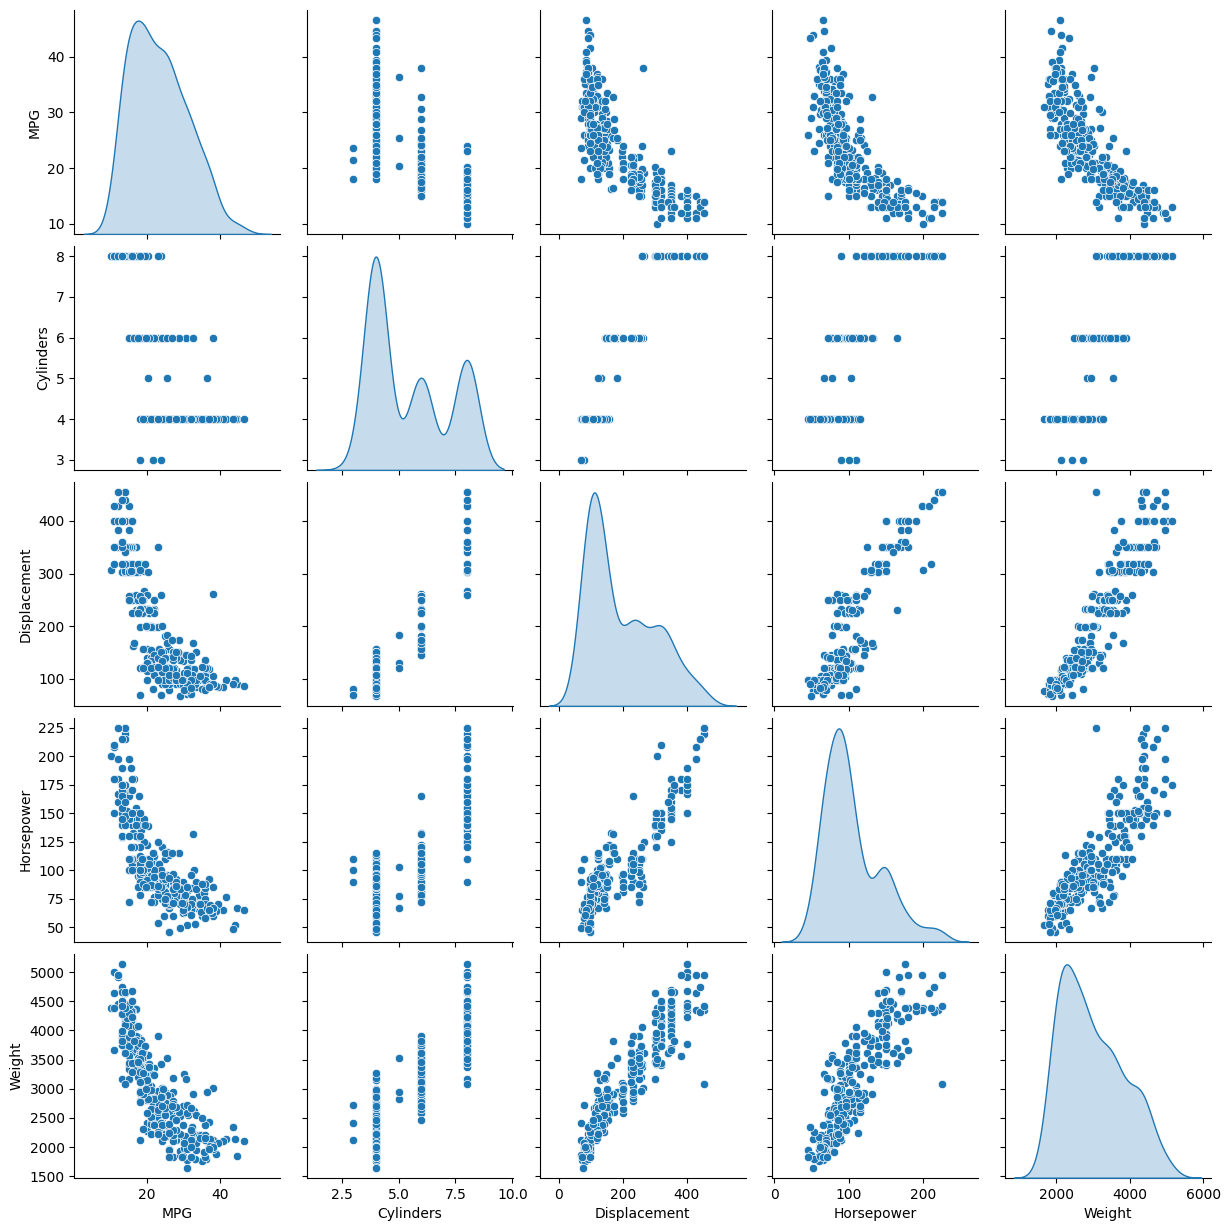

In [ ]:
#Строим графики попарной зависимости признаков
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight']], diag_kind='kde')

1) обратная лин. зависимость Weight и MPG (вес и расход топлива)
2) Лин. зависимость Displacement и Weight (Объем двигателя и вес)
3) обратная лин. зависимость Housepower и MPG (лош силы и расход топлива)
4) Лин. зависимость Displacement и Housepower (объем двигателя и расход топлива)
5) Лин. зависимость Housepower и Weight

In [ ]:
#Получим описание признаков, трансформировав вывод представления
train_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model_Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [ ]:
#Делим датасет на признаки и на то, что будем предсказывать. Сделаем это с тренировочной и тестирующей частью. Метод pop('MPG') удаляет столбец MPG из DataFrame и возвращает его содержимое.
train_features=train_dataset.copy()
test_features=test_dataset.copy()

train_labels=train_features.pop('MPG')
test_labels=test_features.pop('MPG')

In [ ]:
#Посчитаем среднее и стандартное отклонение для признаков
train_dataset.describe().transpose()[['mean', 'std']]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model_Year,75.898089,3.675642


In [ ]:
#Создадим слой нормализации для масштабирования входных данных.
normalizer=tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))
print(normalizer.mean.numpy())

[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]


Часть 2. Построение линейной модели от количества лошадиных сил Horsepower в автомобиле

In [ ]:
#Создадим переменную horsepower, которая будет содержать массив NumPy со всеми значениями из столбца
# Horsepower в train_features.
horsepower=np.array(train_features['Horsepower'])

In [ ]:
#Пишем нормалайзер, который адаптируется к кол-ву лошадиных сил
horsepower_normalizer=layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Создаем простую линейную модель
horsepower_model=tf.keras.Sequential([
# 1 слой - нормалайзер, который нормализует данные
horsepower_normalizer,
# 2 слой - полносвязный, в котором кол-во нейронов равно 1
layers.Dense(units=1)
])

In [ ]:
#Выведем, как выглядит нейронная сеть
horsepower_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

Модель типа "Последовательная" — слои идут один за другим, как вагоны поезда.

normalization_1 — слой нормализации (номер 1)

dense — полносвязный нейронный слой


Обрабатывает один входной признак - мощность двигателя (Horsepower)

Выдает одно нормализованное значение

Содержит 3 параметра, которые не обучаются во время тренировки

Полносвязный слой (Dense)

Принимает один нейрон от предыдущего слоя

Выдает одно значение - предсказание расхода топлива (MPG)

Содержит 2 параметра, которые обучаются в процессе тренировки

Статистика параметров модели:

Всего параметров в модели: 5

Обучаемых параметров: 2

Необучаемых параметров: 3

Интерпретация результатов:

Данная архитектура представляет собой простейшую линейную регрессию, где модель пытается найти линейную зависимость между мощностью двигателя и расходом топлива. Формула модели: y = w*x + b, где w - вес, b - смещение.

Всего два параметра подлежат обучению - это наклон и сдвиг линии регрессии. Три параметра нормализации остаются постоянными, так как они были предварительно вычислены на основе статистик тренировочных данных.

In [ ]:
#Предскажем выход нейронной сети для 10 первых значений
horsepower_model.predict(horsepower[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


array([[-0.111],
       [-0.063],
       [ 0.205],
       [-0.155],
       [-0.14 ],
       [-0.055],
       [-0.166],
       [-0.14 ],
       [-0.037],
       [-0.063]], dtype=float32)

In [ ]:
#выведем значения, которые мы имеем
train_labels.values[:10]

array([28. , 22.3, 12. , 38. , 33.8, 19.4, 38.1, 30. , 20. , 20. ])

In [ ]:
#Видим, что значения не сильно похожи. Для того, чтобы значения стали похожими,
#надо нашу модель скомпилировать, скорость обучения 0.1.
#В качестве Loss будем брать среднюю абсолютную ошибку (MAE)
horsepower_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.1),
                         loss='mean_absolute_error')

MAE (Mean Absolute Error) — это средняя абсолютная ошибка, одна из ключевых метрик для оценки качества регрессионных моделей.

MAE показывает на сколько в среднем ошибается модель в абсолютных единицах измерения целевой переменной.

MAE = (1/n) * Σ|y_i - ŷ_i|

n — количество наблюдений

y_i — истинное значение

ŷ_i — предсказанное моделью значение

|y_i - ŷ_i| — абсолютная ошибка для i-го наблюдения



In [ ]:
#Запустим обучение: 100 эпох, 20% уходит на тестовую часть
%%time
history=horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    verbose=1,
    validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 22.7416 - val_loss: 22.9361
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.8979 - val_loss: 22.1361
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.8846 - val_loss: 21.3358
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.9000 - val_loss: 20.5359
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.4564 - val_loss: 19.7361
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.0279 - val_loss: 18.9357
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 18.1130 - val_loss: 18.1359
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.9155 - val_loss: 17.3357
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.2452 - val_loss: 16.5357
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.5450 - val_loss: 15.7355
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.8064 - val_loss: 14.9355
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step -

In [ ]:
#Получим DataFrame hist, который содержит информацию о метриках (loss) на каждой эпохе обучения,
# а также номер каждой эпохи.
hist=pd.DataFrame(history.history)
hist['epoch']=history.epoch
hist.tail()

,loss,val_loss,epoch
95,3.804707,4.194116,95
96,3.802807,4.161788,96
97,3.807673,4.175789,97
98,3.802607,4.177760,98
99,3.805859,4.204711,99


In [ ]:
#Создадим функцию, которая обрисует нам значения loss и val_loss
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error[MPG]')
  plt.legend()
  plt.grid(True)

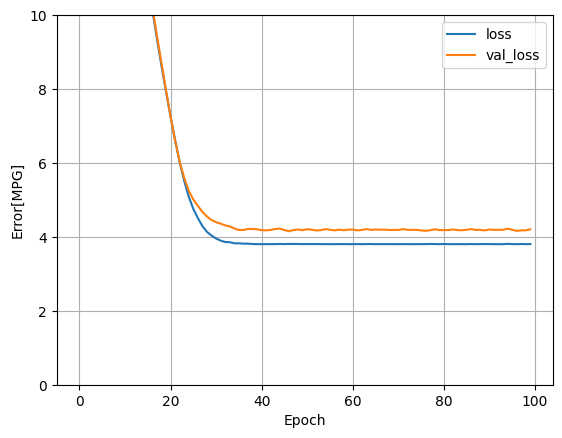

In [ ]:
#Построим график данной функции
plot_loss(history)


In [ ]:
#Создадим словарь test_results, где  будет храниться результат оценки модели
# horsepower_model на тестовых данных
test_results={}
test_results['horsepower_model']=horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels, verbose=0)

In [ ]:
#Рассчитаем ошибку на тестовой части
test_results

{'horsepower_model': 3.6597094535827637}

In [ ]:
#Получим предсказание на тестовой части
x=tf.linspace(0.0, 250, 251)
y=horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


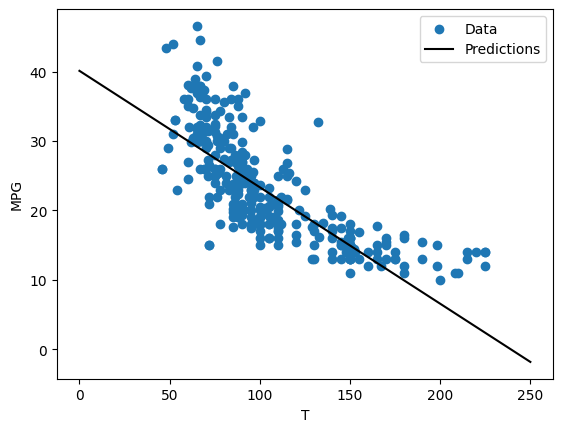

In [ ]:
#Создадим функцию, которая покажет зависимость эффективности автомобиля от признака Horsepower (кол-во лошадиных сил)
def plot_horsepower(x, y):
  plt.scatter(train_features['Horsepower'], train_labels, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('T')
  plt.ylabel('MPG')
  plt.legend()
plot_horsepower(x, y)

Часть 3. Построение линейной модели с использованием всех признаков

In [ ]:
#Модифицируем нашу модель. Будем использовать normalizer, который будет использовать все наши признаки
linear_model=tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

In [ ]:
#Получим предсказание по 10 первым значениям
linear_model.predict(train_features[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step


array([[-0.726],
       [-0.54 ],
       [ 0.625],
       [-0.909],
       [-0.729],
       [-0.745],
       [-0.928],
       [ 0.642],
       [-0.513],
       [-0.476]], dtype=float32)

In [ ]:
#Скомпилируем модель
linear_model.layers[1].kernel

<Variable path=sequential_1/dense_1/kernel, shape=(9, 1), dtype=float32, value=[[ 0.192]
 [-0.687]
 [ 0.665]
 [ 0.399]
 [-0.159]
 [ 0.063]
 [ 0.584]
 [ 0.055]
 [-0.064]]>

In [ ]:
linear_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [ ]:
#Обучим модель
%%time
history=linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=1,
    validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 23.2949 - val_loss: 22.9608
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 21.7521 - val_loss: 22.2504
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 22.1617 - val_loss: 21.5012
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 21.1790 - val_loss: 20.7429
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 20.1999 - val_loss: 20.0257
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.3546 - val_loss: 19.2898
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.9929 - val_loss: 18.5645
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.1127 - val_loss: 17.8271
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 16.4739 - val_loss: 17.0948
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.7286 - val_loss: 16.3932
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14.7914 - val_loss: 15.6514
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

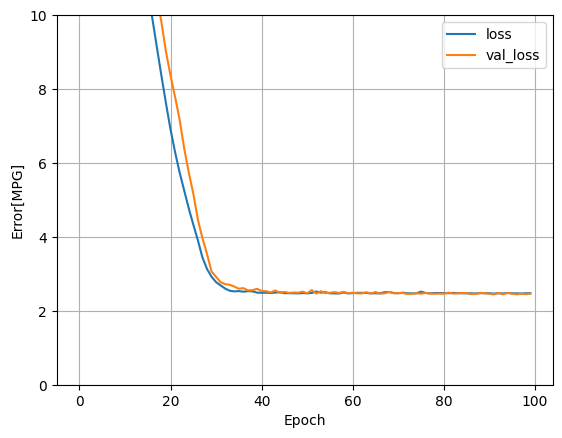

In [ ]:
#Построим график функции, которая обрисует нам значения loss и val_loss
plot_loss(history)

In [ ]:
#Построим test_results для линейной модели
test_results['linear_model']=linear_model.evaluate(test_features, test_labels, verbose=0)

In [ ]:
test_results['linear_model']

2.476201295852661

Часть 4. Построение многослойного персептрона

In [ ]:
#Строим многослойную сеть. Добавляем слои (norm - слой нормализации)
def build_and_compile_model(norm):
  model=keras.Sequential([
    norm,
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)])
  model.compile(loss='mean_absolute_error',
              optimizer=tf.optimizers.Adam(0.001))
  return model

In [ ]:
#Компилируем нашу модель
dnn_horsepower_model=build_and_compile_model(horsepower_normalizer)
dnn_horsepower_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

In [ ]:
#Обучим модель. В качестве признака учтем Horsepower
%%time
history=dnn_horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 11.3 s, sys: 476 ms, total: 11.8 s
Wall time: 12.5 s


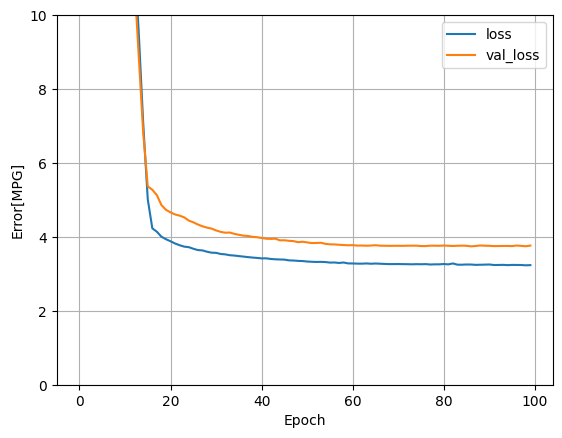

In [ ]:
#Посмотрим, как падала ошибка
plot_loss(history)

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


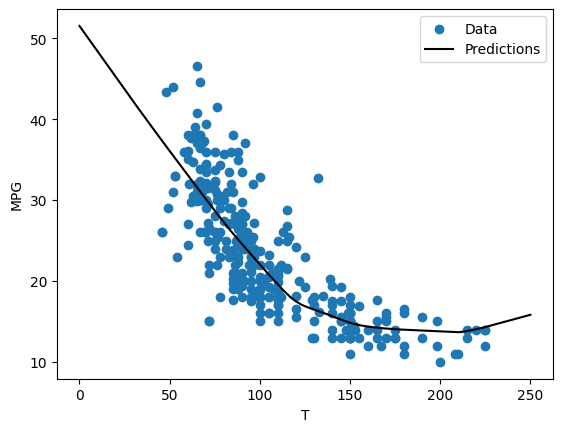

In [ ]:
#Оцените, как модель лучше или хуже описала данные. Как ответите на этот вопрос?
x=tf.linspace(0.0, 250, 251)
y=dnn_horsepower_model.predict(x)
plot_horsepower(x, y)

In [ ]:
#Оценим модель на тестовом наборе данных
test_results['dnn_horsepower_model']=dnn_horsepower_model.evaluate(
    test_features['Horsepower'], test_labels,
    verbose=0)
#Чему равна ошибка  при данной реализации?

In [ ]:
test_results['dnn_horsepower_model']

2.905059337615967

In [ ]:
#Скомпилируем нейонную сеть и выведем информацию о ней.
dnn_model=build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (10, 9)                │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [ ]:
#Обучим модель на всех данных
%%time
history=dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 12.3 s, sys: 477 ms, total: 12.8 s
Wall time: 13.5 s


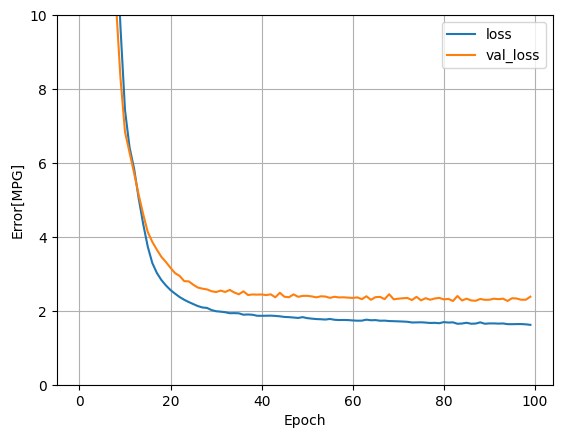

In [ ]:
#Посмотрим поведение ошибки
plot_loss(history)

In [ ]:
#Оценим модель на тестовом наборе данных
test_results['dnn_model']=dnn_model.evaluate(test_features, test_labels, verbose=0)
#Чему равна ошибка  при данной реализации?

In [ ]:
test_results['dnn_model']

1.6853750944137573

Часть 5. Подведем итог

In [ ]:
#Выведем ошибку для каждой модели
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T
#Какая модель показала наилучший результат? dnn_model

,Mean absolute error [MPG]
horsepower_model,3.659709
linear_model,2.476201
dnn_horsepower_model,2.905059
dnn_model,1.685375


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


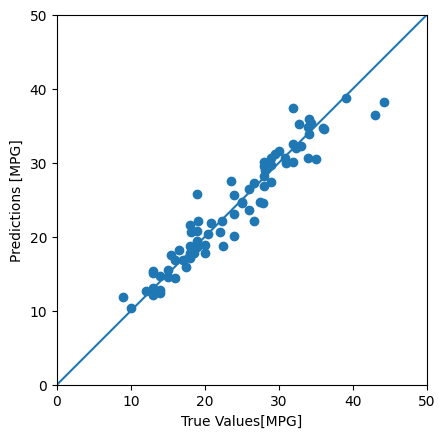

In [ ]:
#Предскажем значения для тестовой выборки и визуализируем результаты в виде диаграммы рассеяния, позволяя оценить, насколько хорошо модель предсказывает истинные значения
test_predictions=dnn_model.predict(test_features).flatten()

a=plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values[MPG]')
plt.ylabel('Predictions [MPG]')
lims=[0, 50]
plt.xlim(lims)
plt.ylim(lims)
y=plt.plot(lims, lims)

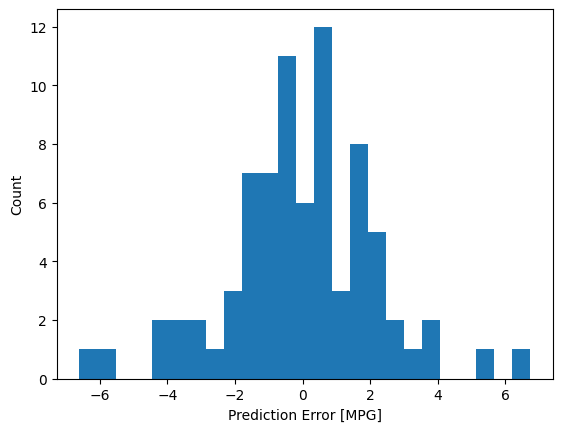

In [ ]:
#Строим гистограмму распределений ошибок.:
error=test_predictions-test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [MPG]')
_=plt.ylabel('Count')

Они близки к нормальному распределению и стремятся к 0.
Сделайте вывод по полученной реализации: какая модель показала лучшие результаты. На основании чего, Вы можете так считать?

dnn_model так как она ошибается реже других